<a href="https://colab.research.google.com/github/rd0820121-web/Rahul-DSBDA-PRATICALS/blob/main/DSBDA_Rahul_Pratical_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [2]:
np.random.seed(42)

data = {
    "Student_ID": range(1, 21),
    "Math_Score": [78, 85, np.nan, 90, 88, 76, 95, 69, 80, 84, 72, 91, 77, 83, 68, 89, 92, 74, 81, 150],  # 150 = outlier
    "English_Score": [75, 82, 70, np.nan, 85, 73, 92, 68, 79, 81, 74, 90, 76, 80, 69, 87, 91, 72, 78, 84],
    "Science_Score": [80, 86, 65, 91, 89, 78, 94, 70, 82, np.nan, 73, 93, 79, 84, 67, 88, 90, 75, 83, 86],
    "Attendance_Percentage": [85, 90, 78, 95, 92, 88, 97, 80, 84, 89, 82, 96, 87, 91, 79, 93, 98, 83, 86, 94]
}

In [3]:
df = pd.DataFrame(data)
print(df)

    Student_ID  Math_Score  English_Score  Science_Score  \
0            1        78.0           75.0           80.0   
1            2        85.0           82.0           86.0   
2            3         NaN           70.0           65.0   
3            4        90.0            NaN           91.0   
4            5        88.0           85.0           89.0   
5            6        76.0           73.0           78.0   
6            7        95.0           92.0           94.0   
7            8        69.0           68.0           70.0   
8            9        80.0           79.0           82.0   
9           10        84.0           81.0            NaN   
10          11        72.0           74.0           73.0   
11          12        91.0           90.0           93.0   
12          13        77.0           76.0           79.0   
13          14        83.0           80.0           84.0   
14          15        68.0           69.0           67.0   
15          16        89.0           87.

In [4]:
df.loc[3, 'Math_Score'] = np.nan
df.loc[7, 'English_Score'] = np.nan

print("Missing Values per column:")
print(df.isnull().sum())

Missing Values per column:
Student_ID               0
Math_Score               2
English_Score            2
Science_Score            1
Attendance_Percentage    0
dtype: int64


In [9]:
df ['Math_Score'].fillna(df['Math_Score'].median(), inplace=True)
df ['English_Score'].fillna(df['English_Score'].median(), inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Student_ID               0
Math_Score               0
English_Score            0
Science_Score            1
Attendance_Percentage    0
dtype: int64


/tmp/ipykernel_3587/2750307142.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df ['Math_Score'].fillna(df['Math_Score'].median(), inplace=True)
/tmp/ipykernel_3587/2750307142.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [16]:
numeric_cols=['Math_Score', 'English_Score', 'Science_Score", "Attendance_Percentage']

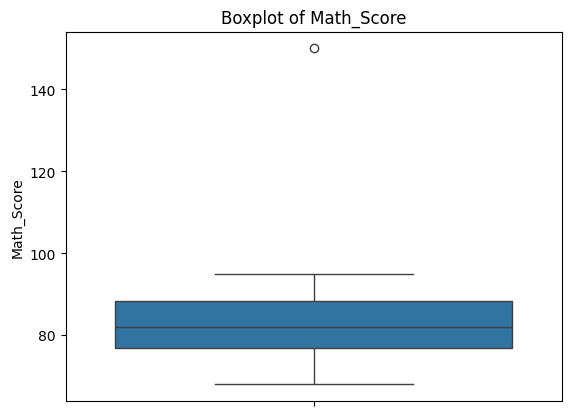

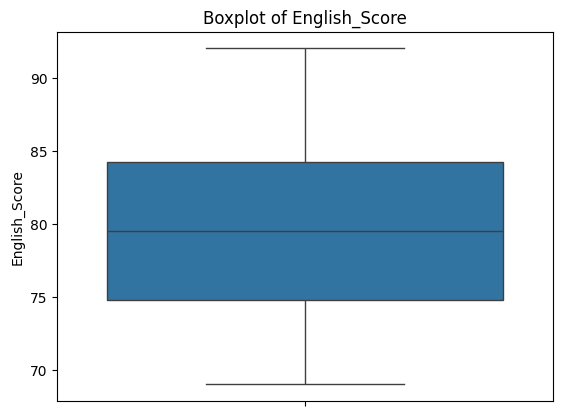

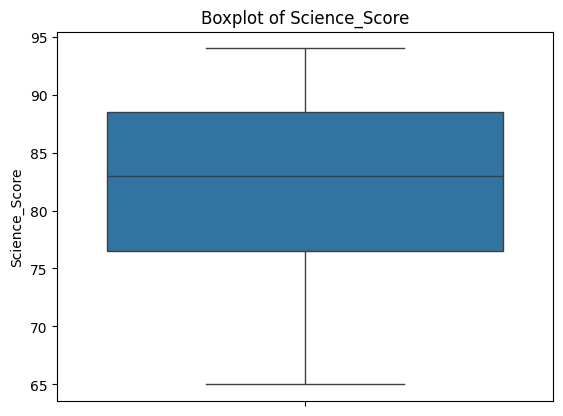

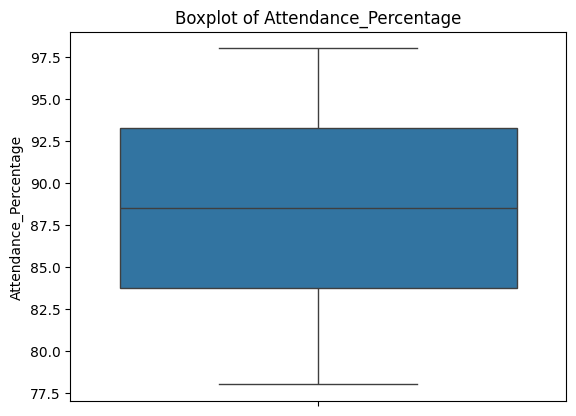

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Math_Score', 'English_Score', 'Science_Score', 'Attendance_Percentage']

for col in numeric_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [20]:
z scores = np.abs(zscore(df[numeric_cols]))

SyntaxError: invalid syntax (45558116.py, line 1)

In [21]:
from scipy.stats import zscore
import numpy as np

# Calculate Z-scores
z_scores = np.abs(zscore(df[numeric_cols]))

# Identify outliers
outliers = (z_scores > 3).any(axis=1)

print("\nRows with potential outliers:")
print(df[outliers])


Rows with potential outliers:
    Student_ID  Math_Score  English_Score  Science_Score  \
19          20       150.0           84.0           86.0   

    Attendance_Percentage  
19                     94  


In [23]:
import numpy as np

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("\nData after outliers capping:")
print(df)


Data after outliers capping:
    Student_ID  Math_Score  English_Score  Science_Score  \
0            1       78.00          75.00          80.00   
1            2       85.00          82.00          86.00   
2            3       82.00          70.00          65.36   
3            4       82.00          79.50          91.00   
4            5       88.00          85.00          89.00   
5            6       76.00          73.00          78.00   
6            7       95.00          91.81          93.82   
7            8       69.00          79.50          70.00   
8            9       80.00          79.00          82.00   
9           10       84.00          81.00            NaN   
10          11       72.00          74.00          73.00   
11          12       91.00          90.00          93.00   
12          13       77.00          76.00          79.00   
13          14       83.00          80.00          84.00   
14          15       68.19          69.19          67.00   
15        

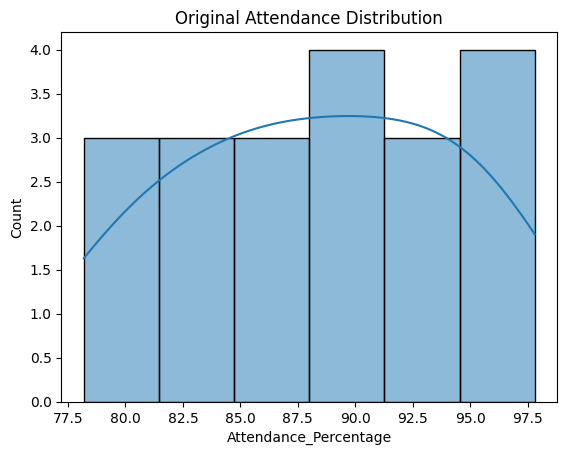

In [25]:
sns.histplot(df['Attendance_Percentage'], kde=True)
plt.title("Original Attendance Distribution")
plt.show()

In [26]:
df['Attendance_Log'] = np.log(df['Attendance_Percentage'])


In [27]:
df['Attendance_Log']

,Attendance_Log
0,4.442651
1,4.499810
2,4.359142
3,4.553877
4,4.521789
5,4.477337
6,4.574711
7,4.382027
8,4.430817
9,4.488636


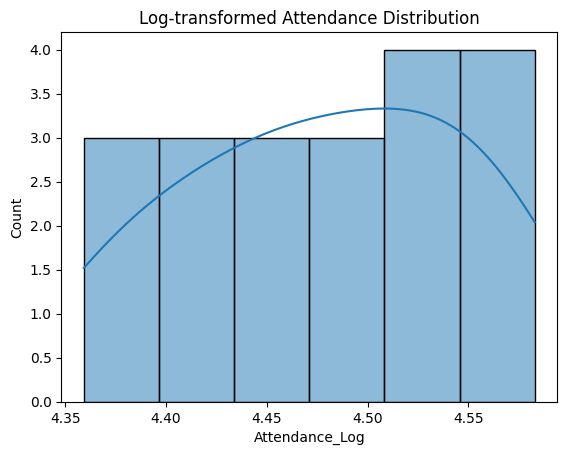

In [28]:
sns.histplot(df ['Attendance_Log'], kde=True)
plt.title("Log-transformed Attendance Distribution")
plt.show()

In [29]:
print("\nSummary statistics after cleaning and transformation:")
print(df.describe())


Summary statistics after cleaning and transformation:
       Student_ID  Math_Score  English_Score  Science_Score  \
count    20.00000   20.000000      20.000000      19.000000   
mean     10.50000   84.287000      79.850000      81.746316   
std       5.91608   14.977371       6.756604       8.600321   
min       1.00000   68.190000      69.190000      65.360000   
25%       5.75000   76.750000      74.750000      76.500000   
50%      10.50000   82.000000      79.500000      83.000000   
75%      15.25000   88.250000      84.250000      88.500000   
max      20.00000  139.550000      91.810000      93.820000   

       Attendance_Percentage  Attendance_Log  
count               20.00000       20.000000  
mean                88.35000        4.479009  
std                  6.11737        0.069695  
min                 78.19000        4.359142  
25%                 83.75000        4.427823  
50%                 88.50000        4.482987  
75%                 93.25000        4.535273  
m